<a href="https://colab.research.google.com/github/gulshan0201/Soft_computing-/blob/main/Logistic_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

import numpy as np

x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])

# Initialize weights and bias
w = np.array([0.2, -0.1], dtype=float)
b = 0.0

eta = 0.1
epochs = 5

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

errors_per_epoch = []

# Training
for epoch in range(epochs):
    total_error = 0

    for i in range(len(x)):
        z = np.dot(w, x[i]) + b
        y_hat = sigmoid(z)

        error = y[i] - y_hat

        # Gradient descent update
        w = w + eta * error * x[i]
        b = b + eta * error

        if abs(error) > 0.5:
            total_error += 1

    errors_per_epoch.append(total_error)

# Final predictions
predictions = []
for i in range(len(x)):
    z = np.dot(w, x[i]) + b
    prob = sigmoid(z)
    predictions.append(1 if prob >= 0.5 else 0)

predictions = np.array(predictions)

print("Errors in each epoch:", errors_per_epoch)
print("Final Weights:", w)
print("Final Bias:", b)
print("Final Predictions:", predictions)

Errors in each epoch: [1, 1, 1, 1, 1]
Final Weights: [0.55645836 0.29601854]
Final Bias: 0.3158927923615206
Final Predictions: [1 1 1 1]


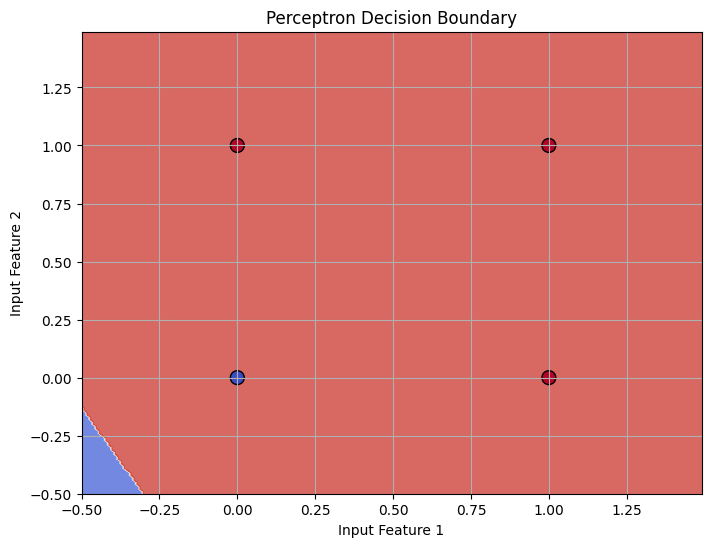

In [6]:
import matplotlib.pyplot as plt

# Create a meshgrid for plotting the decision boundary
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Calculate the output (activation) for each point in the meshgrid
Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b

# Use the sigmoid activation function for the decision boundary visualization
# and classify based on 0.5 threshold
Z = sigmoid(Z).reshape(xx.shape)
Z = (Z >= 0.5).astype(int)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the original data points
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', s=100)

plt.xlabel('Input Feature 1')
plt.ylabel('Input Feature 2')
plt.title('Perceptron Decision Boundary')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid(True)
plt.show()